In [104]:
import matplotlib

%matplotlib inline 
import warnings; warnings.simplefilter('ignore')    # hide warnings

from matplotlib import pyplot as plt
import numpy as np
import seaborn as sb
from scipy import stats
from scipy.stats import binom

import particles
from particles import distributions as dists
from particles import state_space_models as ssm
from particles.collectors import Moments
from particles import mcmc
from collections import OrderedDict

from epydemix import EpiModel
from epydemix import load_predefined_model
from epydemix.visualization import plot_quantiles, plot_trajectories, plot_posterior_distribution_2d
from epydemix.population import load_epydemix_population, Population, get_available_locations
from epydemix.visualization import plot_contact_matrix, plot_population
from epydemix.utils import compute_simulation_dates
from epydemix import simulate
from epydemix.calibration import ABCSampler, rmse
import matplotlib.pyplot as plt
import pandas as pd
import time

# Particles SIR Model

In [13]:
# class DiscreteDist copied from Particles documentation, no changes made except dim is 2 for multivariate
class DiscreteDist:
    dim = 2     # multivariate distribution (default is 1 for univariate)
    dtype = np.int64

    def shape(self, size):
        if size is None:
            return None
        else:
            return (size,) if self.dim == 1 else (size, self.dim)
        
    def logpdf(self, x):
        raise NotImplementedError
    
    def pdf(self, x):
        return np.exp(self.logpdf(x))
    
    def rvs(self, size=None):
        raise NotImplementedError
    
    def ppf(self, u):
        raise NotImplementedError
    

# changed the order of n & p to align with scipy.stats documentation
class NegativeBinomial(DiscreteDist):
    def __init__(self, n=1, p=0.5):
        self.n = n
        self.p = p
    def rvs(self, size = None):
        return np.random.negative_binomial(self.n, self.p, size=size)
    def logpdf(self,x):
        return stats.nbinom.logpmf(x, self.n, self.p) # changed the order of n & p
    def ppf(self, u):
        return stats.nbinom.ppf(u, self.n, self.p) # changed the order of n & p

In [14]:

def Initial(N):  # where xp = X_{t-1}
    
    chainrule = OrderedDict()
    chainrule['new_inf'] = dists.Dirac(0)
    chainrule['new_rec'] = dists.Dirac(0)
    chainrule['S'] = dists.Dirac(N-1)
    chainrule['I'] = dists.Dirac(1)
    chainrule['R'] = dists.Dirac(0)
    return dists.StructDist(chainrule)

# Chain binomial process
def Binomial(xp, beta, gamma, N):  # where xp = X_{t-1}
    # probabilites for new infetions and recoveries
    infection_prob = 1 - np.exp(-beta * xp['I'] / N)
    recovery_prob = 1 - np.exp(-gamma)
    # probability = np.clip(probability, 0, 1)
    
    # Update compartments
    chainrule = OrderedDict()
    chainrule['new_inf'] = dists.Binomial(n = xp['S'].astype(int), p = infection_prob)
    chainrule['new_rec'] = dists.Binomial(n = xp['I'].astype(int), p = recovery_prob)
    chainrule['S'] = dists.Cond(lambda x: dists.Dirac(xp['S'].astype(int) - x['new_inf']))
    chainrule['I'] = dists.Cond(lambda x: dists.Dirac(xp['I'].astype(int) + x['new_inf'] - x['new_rec']))
    chainrule['R'] = dists.Cond(lambda x: dists.Dirac(xp['R'].astype(int) + x['new_rec']))
    return dists.StructDist(chainrule)

In [15]:
# State Space Model

class ChainBinomialModel(ssm.StateSpaceModel):
    default_params = {'N': 10000}
    def PX0(self):                                                      # Initial state of SIR
        return Initial(10000)
    def PX(self, t, xp):                                                # Hidden Markov process
        return Binomial(xp, self.beta, self.gamma, self.N)
    def PY(self, t, xp, x):                                             # Observation model 
        mu = 0.05 * x['I']
        size = 2
        mu2 = np.maximum(mu, 1e-6)
        p = size/(size + mu2)
        return NegativeBinomial(n = size, p = p)

In [16]:
ChainBin = ChainBinomialModel(beta = 0.3, gamma = 0.1)
x, y = ChainBin.simulate(100)

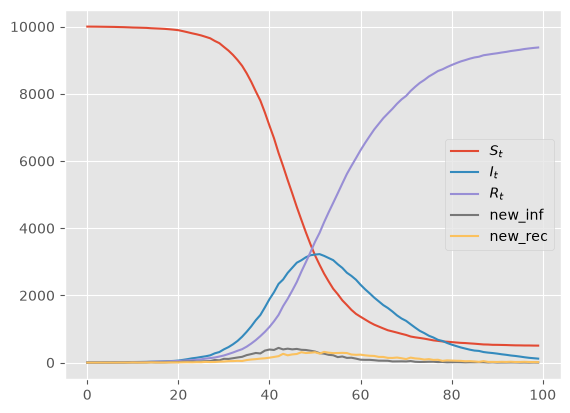

In [17]:
plt.style.use('ggplot')
plt.plot([xt['S'] for xt in x], label=r'$S_t$')
plt.plot([xt['I'] for xt in x], label=r'$I_t$')
plt.plot([xt['R'] for xt in x], label=r'$R_t$')
plt.plot([xt['new_inf'] for xt in x], label='new_inf')
plt.plot([xt['new_rec'] for xt in x], label='new_rec')
plt.legend()

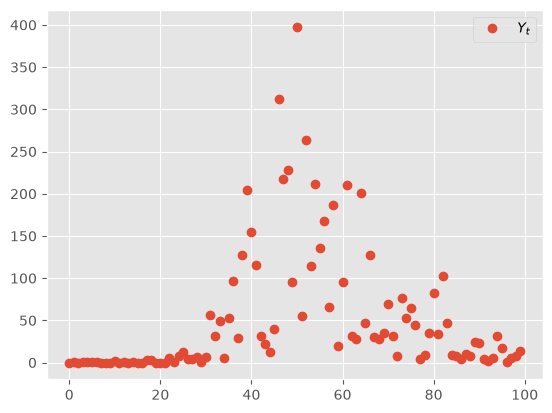

In [18]:
plt.style.use('ggplot')
plt.plot(y, label=r'$Y_t$', linestyle='', marker='o')

plt.legend()

In [66]:
fk = ssm.Bootstrap(ssm=ChainBin, data=y)
alg = particles.SMC(fk=fk, 
                    N=100,
                    resampling = 'systematic', 
                    verbose=True)
alg.run()

t=0: resample:False, ESS (end of iter)=100.00
t=1: resample:False, ESS (end of iter)=81.59
t=2: resample:False, ESS (end of iter)=84.15
t=3: resample:False, ESS (end of iter)=47.86
t=4: resample:True, ESS (end of iter)=80.69
t=5: resample:False, ESS (end of iter)=59.33
t=6: resample:False, ESS (end of iter)=47.12
t=7: resample:True, ESS (end of iter)=95.58
t=8: resample:False, ESS (end of iter)=82.27
t=9: resample:False, ESS (end of iter)=63.84
t=10: resample:False, ESS (end of iter)=85.05
t=11: resample:False, ESS (end of iter)=72.10
t=12: resample:False, ESS (end of iter)=68.65
t=13: resample:False, ESS (end of iter)=51.35
t=14: resample:False, ESS (end of iter)=47.08
t=15: resample:True, ESS (end of iter)=83.81
t=16: resample:False, ESS (end of iter)=54.23
t=17: resample:False, ESS (end of iter)=80.54
t=18: resample:False, ESS (end of iter)=78.94
t=19: resample:False, ESS (end of iter)=65.76
t=20: resample:False, ESS (end of iter)=48.28
t=21: resample:True, ESS (end of iter)=77.95
t

In [94]:
print(alg.cpu_time)

0.02006458304822445


In [96]:
outf = lambda pf: pf.logLt
alg_parallel = particles.multiSMC(fk=fk,
                                  N=[100, 500, 1000],
                                  resampling='systematic',
                                  verbose=True,
                                  )

t=0: resample:False, ESS (end of iter)=1000.00
t=1: resample:False, ESS (end of iter)=812.85
t=2: resample:False, ESS (end of iter)=835.39
t=3: resample:False, ESS (end of iter)=498.46
t=0: resample:False, ESS (end of iter)=500.00
t=1: resample:False, ESS (end of iter)=412.47
t=2: resample:False, ESS (end of iter)=422.30
t=3: resample:False, ESS (end of iter)=267.91
t=0: resample:False, ESS (end of iter)=100.00
t=4: resample:False, ESS (end of iter)=161.73
t=1: resample:False, ESS (end of iter)=82.92
t=2: resample:False, ESS (end of iter)=85.00
t=3: resample:False, ESS (end of iter)=57.48
t=4: resample:False, ESS (end of iter)=37.36
t=0: resample:False, ESS (end of iter)=100.00
t=1: resample:False, ESS (end of iter)=82.27
t=2: resample:False, ESS (end of iter)=84.58
t=3: resample:False, ESS (end of iter)=52.55
t=4: resample:False, ESS (end of iter)=33.67
t=0: resample:False, ESS (end of iter)=500.00
t=1: resample:False, ESS (end of iter)=407.96
t=2: resample:False, ESS (end of iter)=41

In [103]:
print(alg_parallel[0]['output'].W)



[1.56454008e-02 2.82828991e-02 1.40186726e-02 9.99767328e-03
 6.82819070e-03 1.46436410e-02 2.12460874e-02 1.00631795e-02
 2.17572502e-02 1.46004700e-02 6.56696454e-03 5.23788954e-03
 4.67758158e-03 7.24029718e-03 9.61460558e-03 1.69663248e-02
 4.31720337e-03 6.23860543e-03 3.78751751e-03 9.60741695e-03
 6.83012815e-03 3.48956679e-03 1.19550417e-02 1.18973356e-02
 1.26913229e-02 7.62821725e-03 9.76554200e-03 7.48651104e-03
 6.11694513e-03 1.73356857e-02 6.58068823e-03 7.51748716e-03
 4.25446098e-03 3.12817503e-02 2.79544033e-02 3.34148640e-03
 3.41542145e-05 8.99518482e-03 1.21002636e-02 1.41610791e-02
 1.74208749e-02 5.25301758e-03 7.72267475e-03 9.80709716e-03
 1.29165610e-02 5.96703316e-03 4.17135072e-03 1.64072670e-02
 7.84750212e-03 6.50302860e-03 4.82138737e-04 2.62287372e-02
 7.05857267e-03 7.02004706e-03 5.51208296e-03 4.05686393e-03
 6.23418674e-03 1.01150630e-02 1.22382958e-02 8.99093009e-03
 2.25289965e-02 1.12701289e-02 4.57583451e-03 2.83729506e-03
 9.77791392e-04 4.361961

In [67]:
class ScalarStructDist(dists.StructDist):
    def logpdf(self, theta):
        out = super().logpdf(theta)
        if isinstance(out, np.ndarray) and out.shape == (1,):
            return out[0]
        return out

In [68]:
prior_dict = {'beta': dists.Uniform(a=0.1, b=0.4),
              'gamma': dists.Uniform(a= 0.05, b= 0.15)}  # Uniform distribution because the prior is uninformative

my_prior = ScalarStructDist(prior_dict)      # need this because 'dict' object has no attribute 'dtype' but StructDist does

In [85]:
%%capture
pmmh = mcmc.PMMH(ssm_cls= ChainBinomialModel, prior = my_prior, data=y, Nx=5000, niter=1000, adaptive=True, smc_options={"resampling": "systematic", "verbose": True})
pmmh.run()

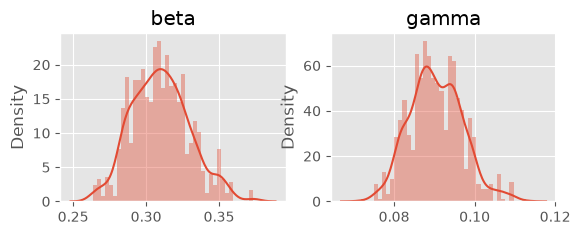

In [70]:
# plot the marginals
burnin = 100
for i, param in enumerate(prior_dict.keys()):
    plt.subplot(2, 2, i+1)
    sb.distplot(pmmh.chain.theta[param][burnin:], 40)
    plt.title(param)

In [71]:
print(len(np.array(y)))

100


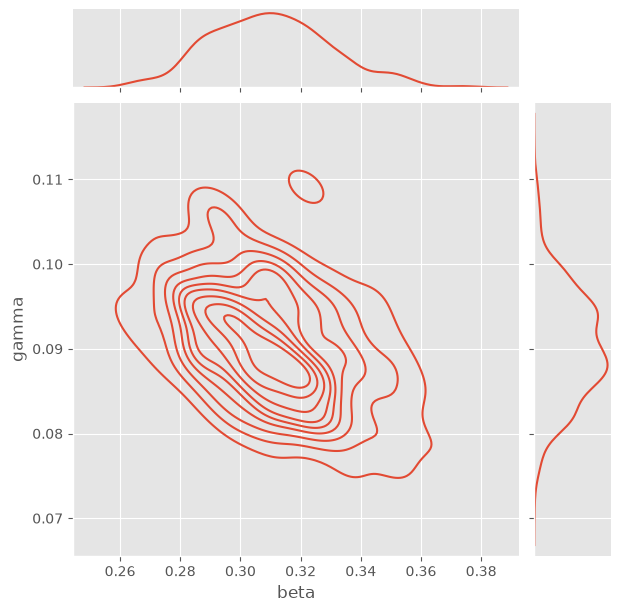

In [72]:
beta_density = pmmh.chain.theta['beta'][burnin:]
gamma_density = pmmh.chain.theta['gamma'][burnin:]
sb.jointplot(x = beta_density, y = gamma_density, kind = 'kde')
plt.xlabel('beta')
plt.ylabel('gamma')
plt.show()

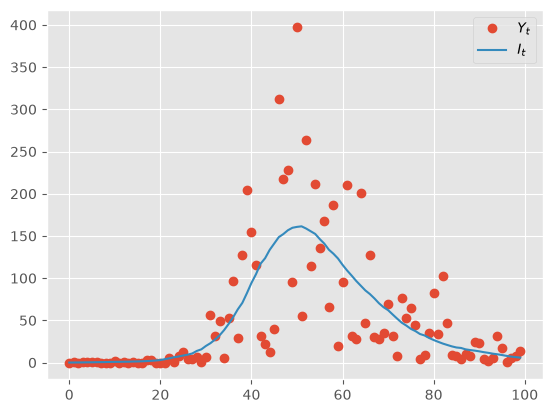

In [73]:
plt.style.use('ggplot')
plt.plot(y, label=r'$Y_t$', linestyle='', marker='o')
plt.plot([xt['I']*.05 for xt in x], label=r'$I_t$')
plt.legend()

In [74]:
df = pd.DataFrame(y)
df.rename(columns={0: 'data'}, inplace=True)
df['date'] = pd.date_range(start = '2024/01/01', periods = len(df), freq='D')
print(df)

    data       date
0      0 2024-01-01
1      1 2024-01-02
2      0 2024-01-03
3      1 2024-01-04
4      1 2024-01-05
..   ...        ...
95    17 2024-04-05
96     1 2024-04-06
97     5 2024-04-07
98     8 2024-04-08
99    14 2024-04-09

[100 rows x 2 columns]


# Epydemix SIR Model (custom)

In [75]:
def stochastic_sir(S_t0, I_t0, R_t0, beta, mu, N, timesteps):
    
    # Simulates a stochastic SIR model using the chain binomial process.
    
    S, I, R = S_t0, I_t0, R_t0
    S_arr, I_arr, R_arr = [S], [I], [R]
    incidence = [0]

    for _ in range(timesteps-1):

        # Infection process (Binomial draw of new infections)
        new_infected = np.random.binomial(S, 1 - np.exp(-beta * I / N))

        # Recovery process
        new_recovered = np.random.binomial(I, 1 - np.exp(-mu))

        # Update compartments
        S -= new_infected
        I += new_infected - new_recovered
        R += new_recovered

        # Store results
        S_arr.append(S)
        I_arr.append(I)
        R_arr.append(R)
        incidence.append(new_infected)

    return {"S": S_arr, "I": I_arr, "R": R_arr, "incidence": incidence}

In [ ]:
Nsim = 50

start = time.time()
sim_results = 

In [116]:
N = 10000
model = stochastic_sir(N - 1, 1, 0, 0.3, 0.1, N, len(df))
print(model)



{'S': [9999, 9999, 9996, 9994, 9994, 9991, 9988, 9985, 9982, 9977, 9975, 9974, 9968, 9964, 9952, 9943, 9934, 9919, 9905, 9889, 9870, 9845, 9810, 9767, 9720, 9671, 9616, 9530, 9449, 9337, 9218, 9057, 8876, 8689, 8479, 8236, 7984, 7665, 7340, 6974, 6605, 6245, 5861, 5439, 5004, 4588, 4200, 3837, 3507, 3183, 2923, 2679, 2444, 2246, 2070, 1888, 1726, 1609, 1507, 1401, 1304, 1223, 1144, 1081, 1010, 957, 916, 870, 837, 803, 770, 743, 719, 692, 674, 656, 635, 617, 600, 593, 584, 574, 562, 556, 550, 540, 534, 530, 527, 523, 521, 518, 514, 509, 504, 501, 497, 494, 493, 492], 'I': [1, 1, 4, 6, 6, 9, 10, 11, 13, 15, 15, 14, 20, 23, 31, 39, 47, 59, 67, 76, 88, 106, 132, 167, 198, 230, 262, 323, 371, 447, 536, 644, 743, 852, 972, 1125, 1279, 1489, 1662, 1839, 2005, 2177, 2374, 2563, 2768, 2896, 3013, 3093, 3122, 3162, 3104, 3059, 3022, 2931, 2818, 2714, 2633, 2494, 2362, 2230, 2119, 1987, 1901, 1788, 1687, 1569, 1436, 1346, 1246, 1145, 1079, 1002, 932, 878, 825, 779, 735, 678, 622, 560, 521, 492, 4

In [76]:
data = pd.read_csv('/Users/gabriellebouvier/SIR_Model/Project2/incidence_data.csv')


In [77]:
# priors
priors = {"beta": stats.uniform(0.1, .4), 
          "mu": stats.uniform(0.05, 0.15)}

# simulation parameters
N = 10000 # population
parameters = {"S_t0": N - 1,
              "I_t0": 1,
              "R_t0": 0,
              "N": N,
              "timesteps": len(df)}

# wrapper function
def simulate_wrapper(parameters): 
    results = stochastic_sir(**parameters)
    return {"data": results["incidence"]}

# initialize the ABCSampler object
abc_sampler = ABCSampler(simulation_function=simulate_wrapper, 
                         priors=priors, 
                         parameters=parameters, 
                         observed_data=df["data"].values)

In [ ]:
print(abc_sampler)

TypeError: 'ABCSampler' object is not subscriptable

In [78]:
results = abc_sampler.calibrate(strategy="smc", 
                    num_particles=100, 
                    num_generations=5)

Starting ABC-SMC with 100 particles and 5 generations

Generation 1/5 (epsilon: inf)
	Accepted 100/100 (acceptance rate: 100.00%)
	Elapsed time: 00:00:00

Generation 2/5 (epsilon: 92.916629)
	Accepted 100/286 (acceptance rate: 34.97%)
	Elapsed time: 00:00:00

Generation 3/5 (epsilon: 92.916414)
	Accepted 100/629 (acceptance rate: 15.90%)
	Elapsed time: 00:00:00

Generation 4/5 (epsilon: 92.441484)
	Accepted 100/1171 (acceptance rate: 8.54%)
	Elapsed time: 00:00:00

Generation 5/5 (epsilon: 88.179551)
	Accepted 100/2205 (acceptance rate: 4.54%)
	Elapsed time: 00:00:00


<Axes: >

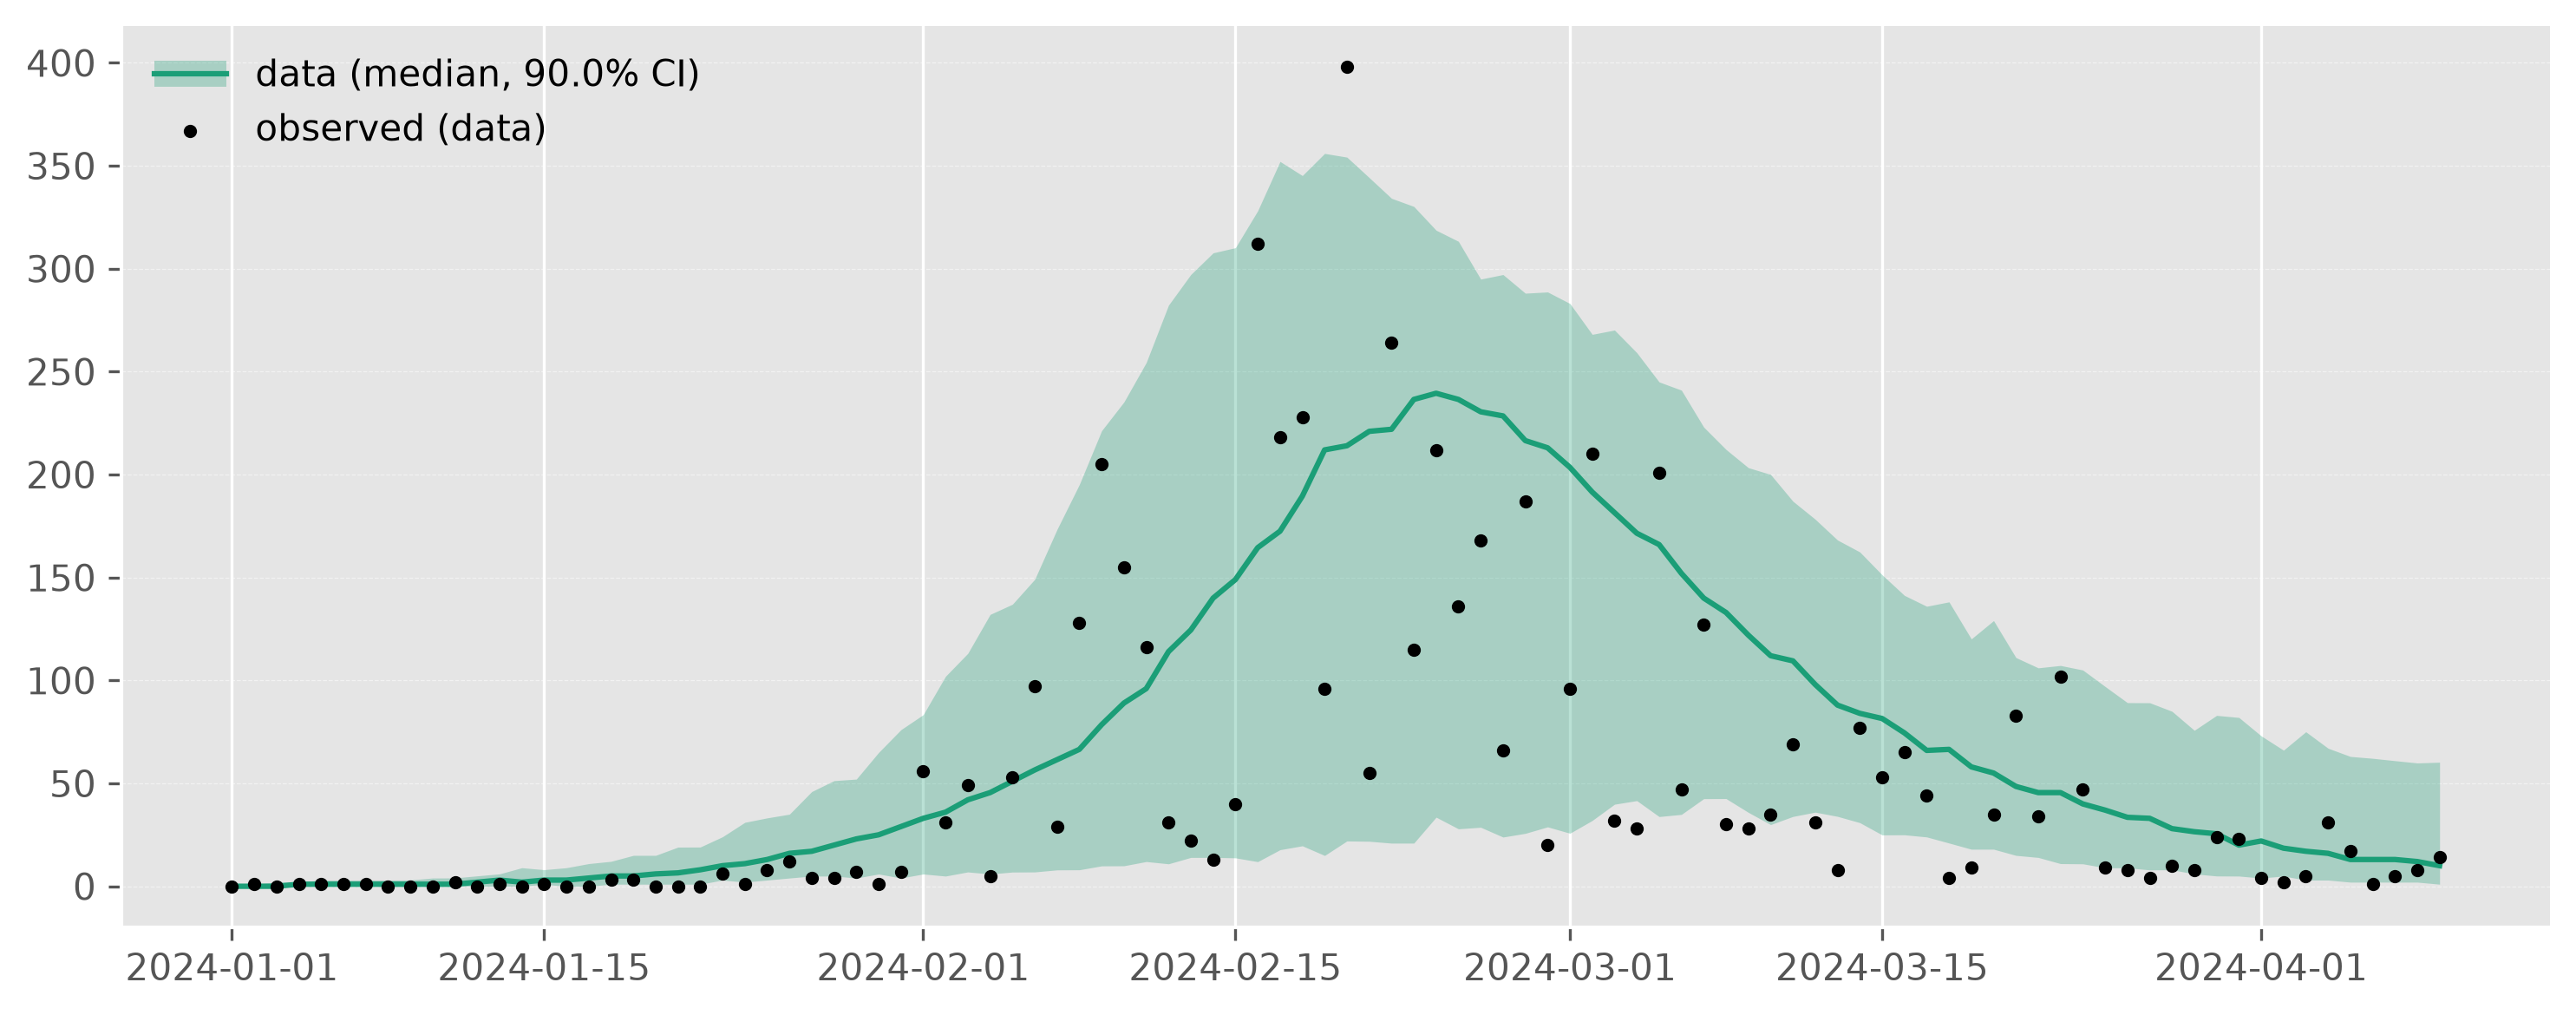

In [79]:
df_quantiles_calibration = results.get_calibration_quantiles(df["date"])
plot_quantiles(df_quantiles_calibration, columns="data", data=df, show_legend=True, show_data=True)

In [80]:
print(df_quantiles_calibration)

          date  quantile   data
0   2024-01-01      0.05   0.00
1   2024-01-02      0.05   0.00
2   2024-01-03      0.05   0.00
3   2024-01-04      0.05   0.00
4   2024-01-05      0.05   0.00
..         ...       ...    ...
295 2024-04-05      0.95  63.05
296 2024-04-06      0.95  62.15
297 2024-04-07      0.95  61.00
298 2024-04-08      0.95  59.90
299 2024-04-09      0.95  60.25

[300 rows x 3 columns]


<Axes: title={'center': 'Joint Distribution\nbeta vs mu'}, xlabel='beta', ylabel='mu'>

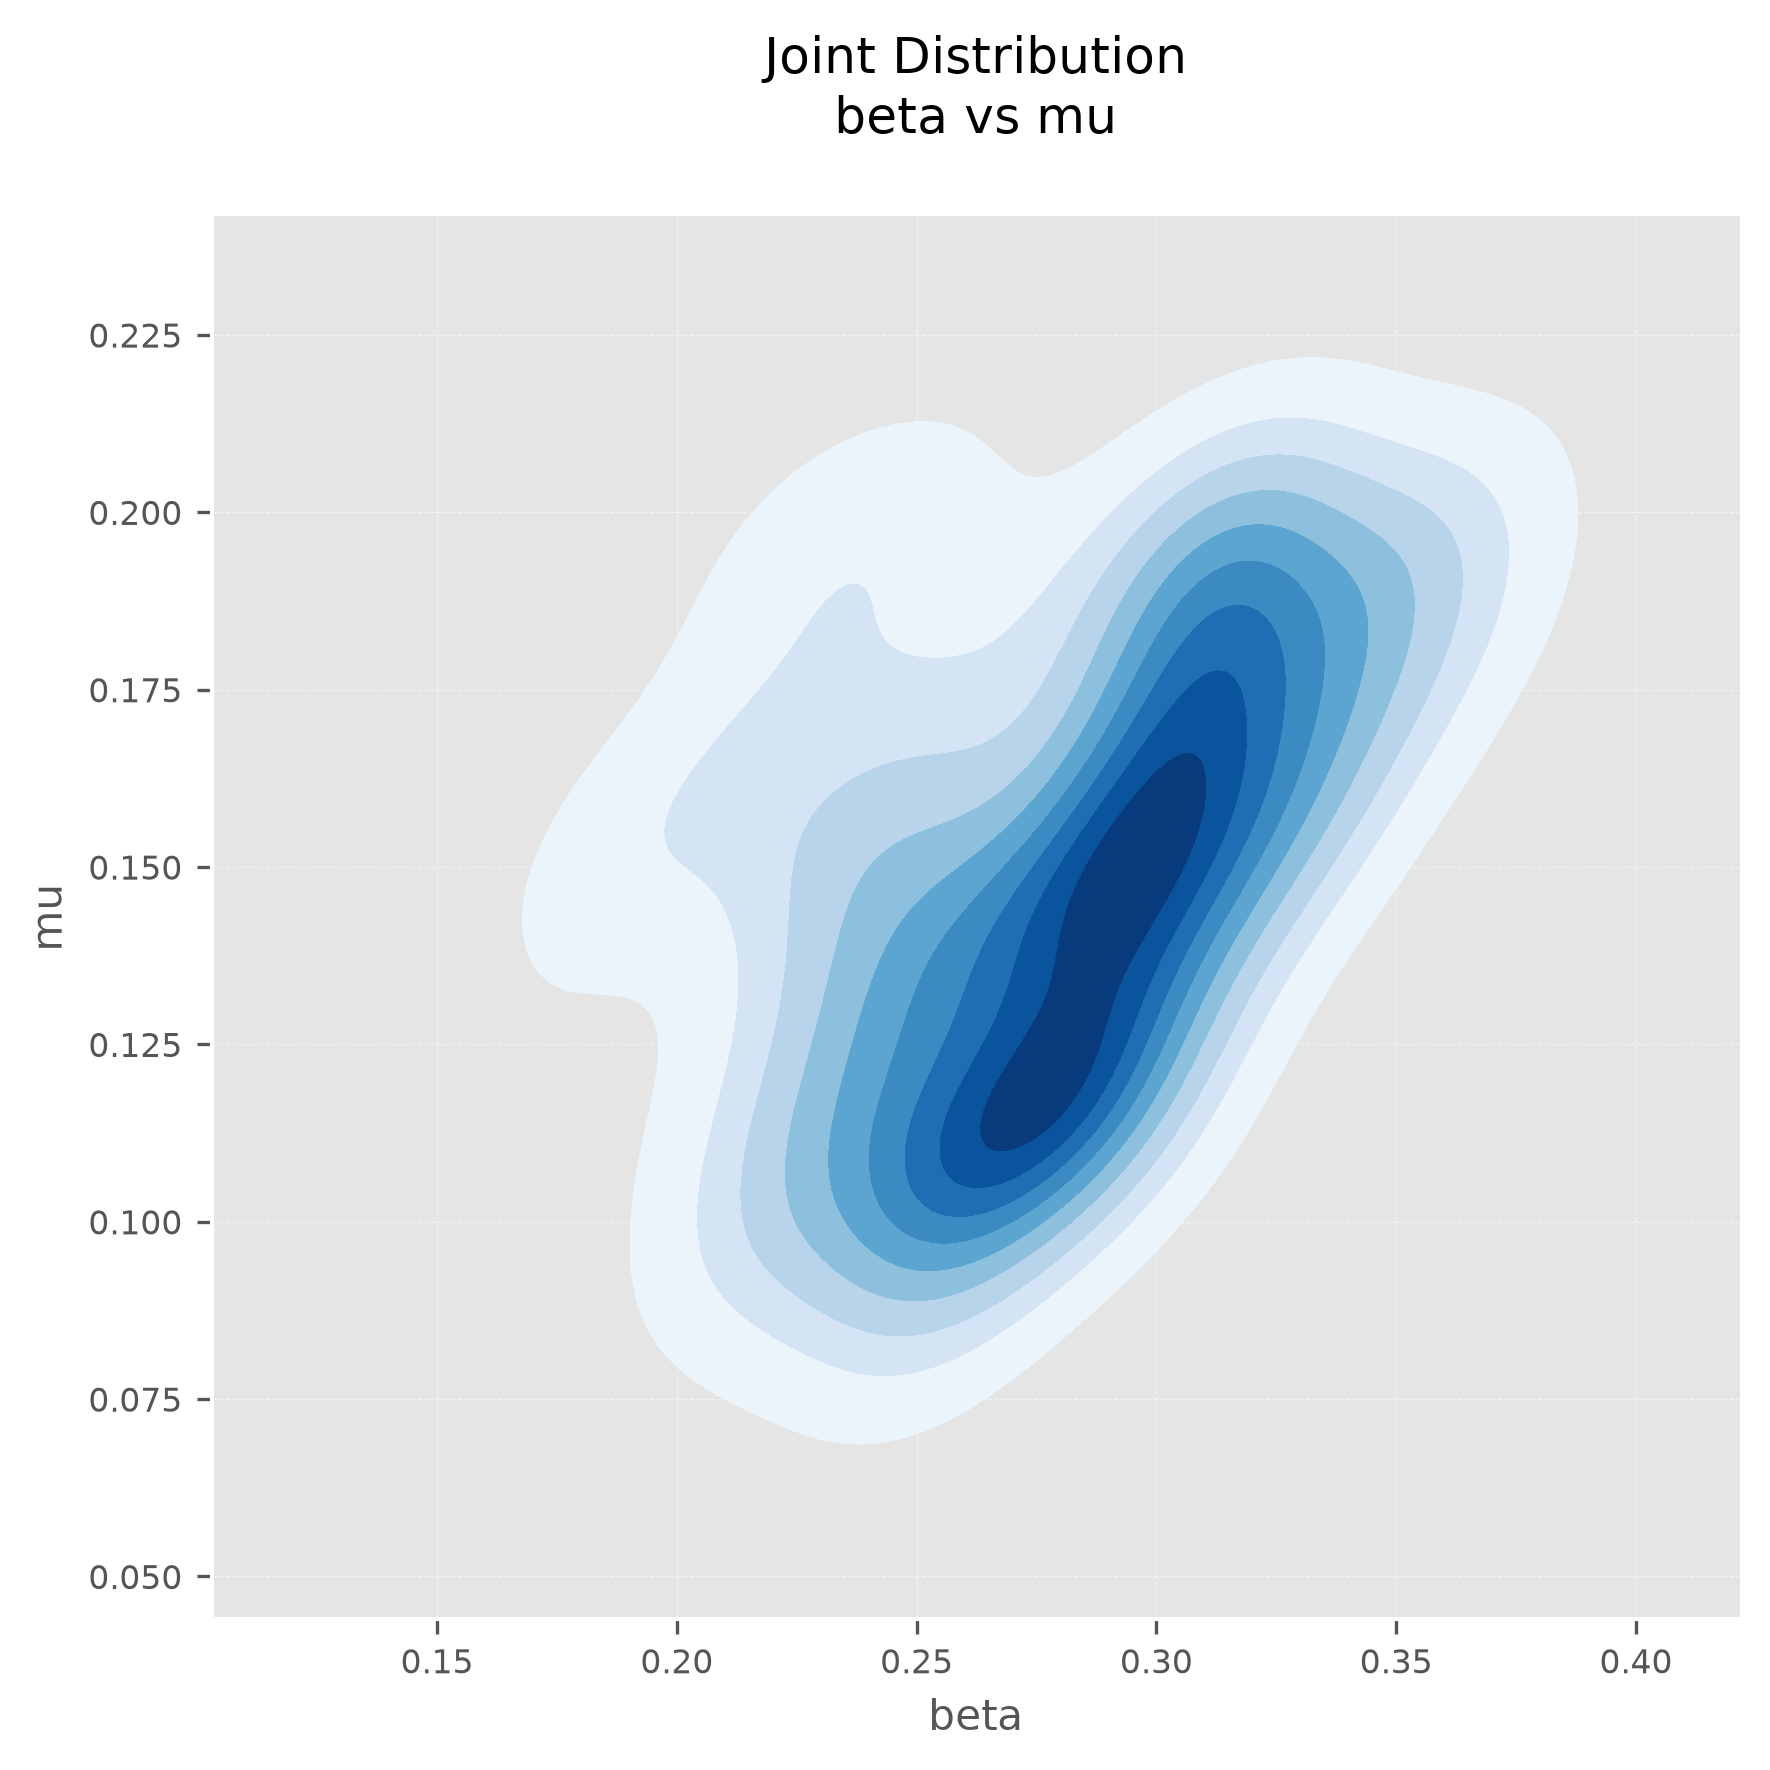

In [81]:
df_posterior = results.get_posterior_distribution()
plot_posterior_distribution_2d(df_posterior, "beta", "mu", kind="kde")

In [82]:
print(df_posterior)

        beta        mu
0   0.284481  0.143489
1   0.298174  0.156195
2   0.364930  0.196767
3   0.340245  0.166204
4   0.238855  0.109456
..       ...       ...
95  0.310612  0.175412
96  0.254612  0.104662
97  0.303875  0.154189
98  0.292836  0.122063
99  0.309981  0.182514

[100 rows x 2 columns]


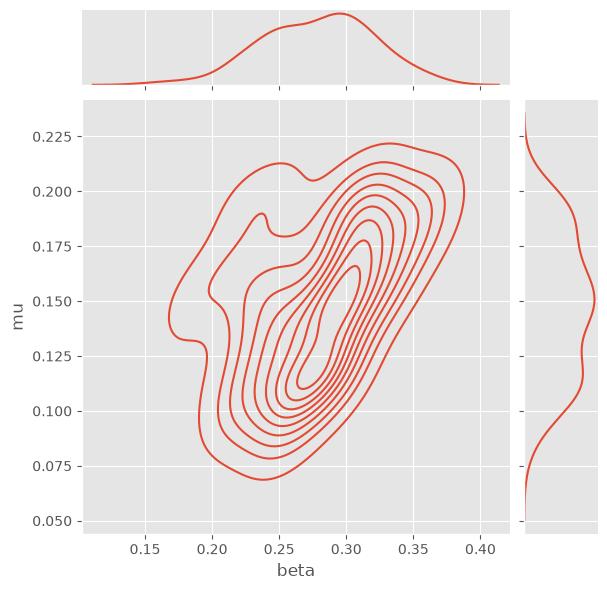

In [83]:
sb.jointplot(x = df_posterior['beta'], y = df_posterior['mu'], kind = 'kde')
plt.xlabel('beta')
plt.ylabel('mu')
plt.show()

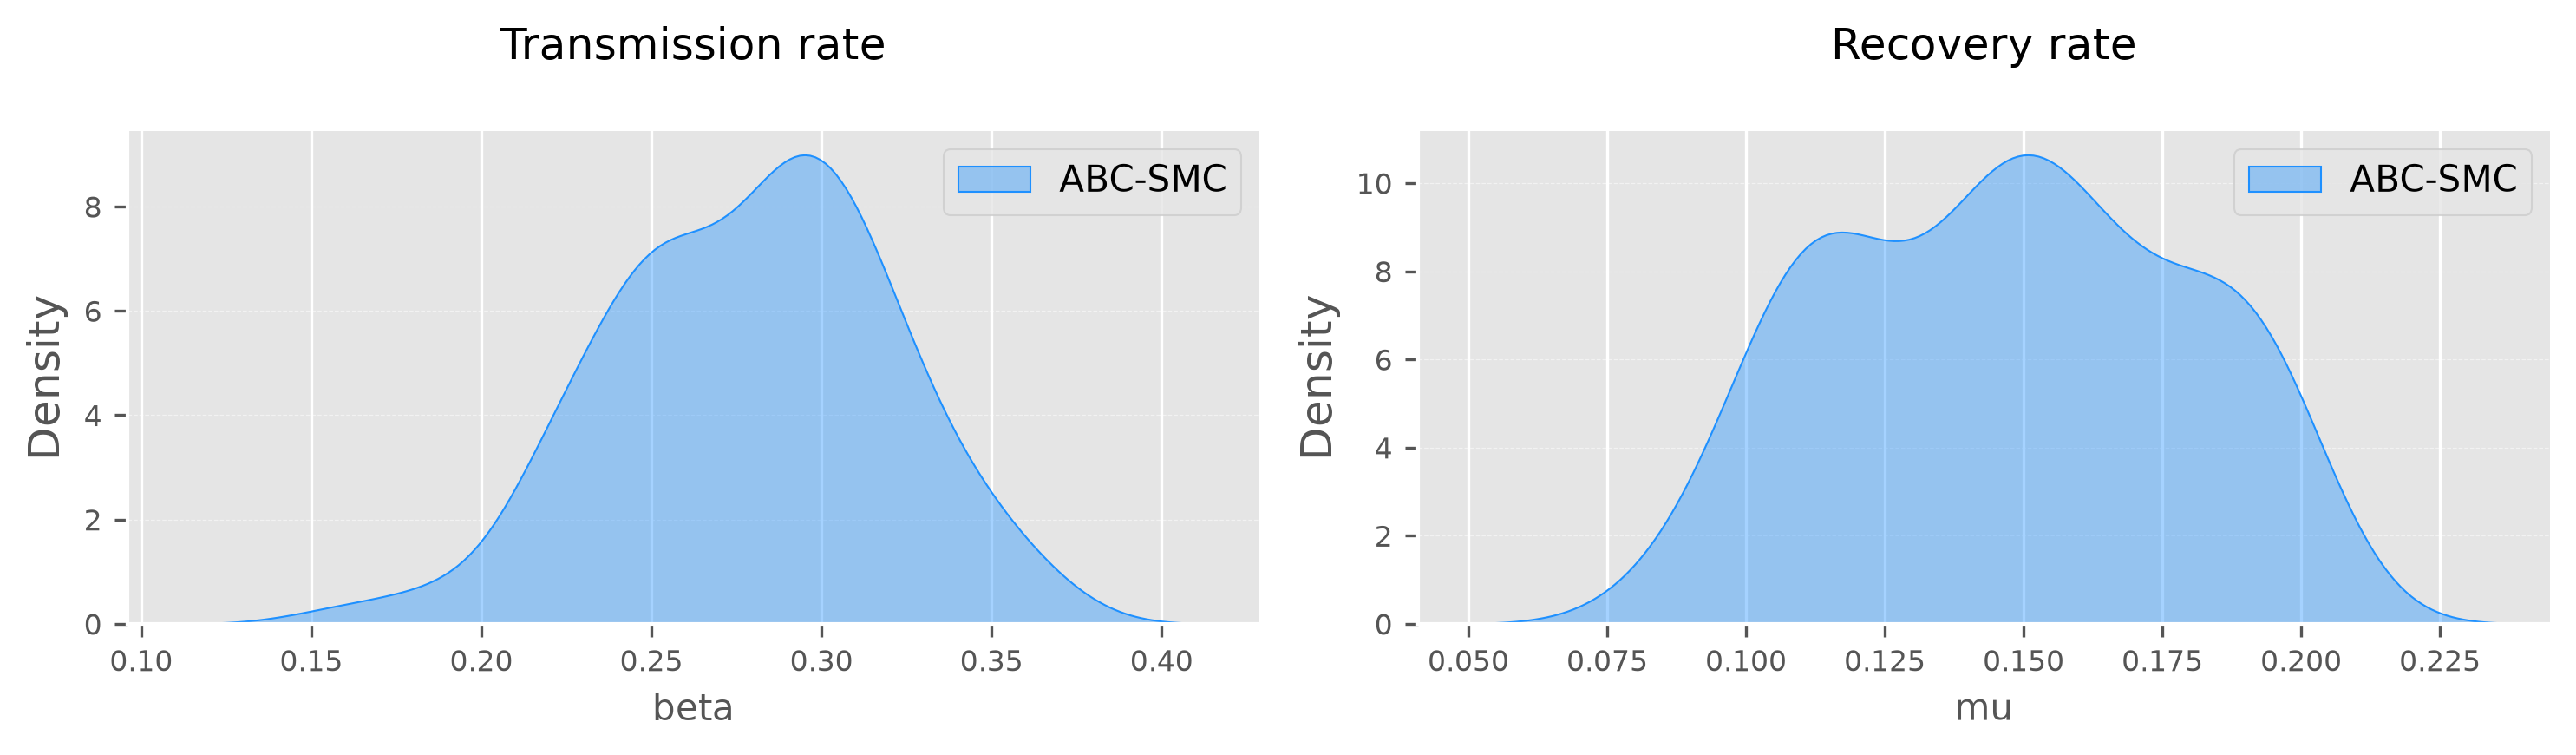

In [84]:
from epydemix.visualization import plot_posterior_distribution

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 3), dpi=300)
plot_posterior_distribution(results.get_posterior_distribution(), "beta", ax=axes[0], kind="kde", title="Transmission rate", prior_range=False, label="ABC-SMC")
axes[0].legend()    

plot_posterior_distribution(results.get_posterior_distribution(), "mu", ax=axes[1], kind="kde", title="Recovery rate", prior_range=False, label="ABC-SMC")
axes[1].legend()